In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [56]:
dataset = pd.read_csv('WSN-DS[1].csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values
feature_names = dataset.columns[1:-1].tolist()  # Convert column names to a list
feature_names = np.array(feature_names)

In [57]:
print(X)
print(y)
print(feature_names)

[[5.0000000e+01 1.0000000e+00 1.0100000e+05 ... 1.3008535e+02
  0.0000000e+00 2.4694000e+00]
 [5.0000000e+01 0.0000000e+00 1.0104400e+05 ... 0.0000000e+00
  4.0000000e+00 6.9570000e-02]
 [5.0000000e+01 0.0000000e+00 1.0101000e+05 ... 0.0000000e+00
  3.0000000e+00 6.8980000e-02]
 ...
 [1.0030000e+03 0.0000000e+00 2.0105700e+05 ... 8.3078970e+01
  1.0000000e+00 2.6304000e-01]
 [1.0030000e+03 0.0000000e+00 2.0108800e+05 ... 1.0308993e+02
  9.0000000e+00 2.5004000e-01]
 [1.0030000e+03 0.0000000e+00 2.0000000e+01 ...           nan
            nan           nan]]
['Normal' 'Normal' 'Normal' ... 'Normal' 'Normal' nan]
[' Time' ' Is_CH' ' who CH' ' Dist_To_CH' ' ADV_S' ' ADV_R' ' JOIN_S'
 ' JOIN_R' ' SCH_S' ' SCH_R' 'Rank' ' DATA_S' ' DATA_R' ' Data_Sent_To_BS'
 ' dist_CH_To_BS' ' send_code ' 'Expaned Energy']


In [58]:
from sklearn.impute import SimpleImputer
import numpy as np

# Impute all features (excluding target)
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imputer.fit_transform(X)  # Make sure X is full features

# Impute target if necessary (use most frequent)
imputer_y = SimpleImputer(strategy='most_frequent')
y = imputer_y.fit_transform(y.reshape(-1, 1)).ravel()


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

             Feature  Importance
4              ADV_S    0.158439
1              Is_CH    0.147083
16    Expaned Energy    0.131515
13   Data_Sent_To_BS    0.098686
8              SCH_S    0.089461
11            DATA_S    0.069469
5              ADV_R    0.039106
0               Time    0.037083
14     dist_CH_To_BS    0.033159
7             JOIN_R    0.031720
10              Rank    0.031364
12            DATA_R    0.030481
2             who CH    0.030351
6             JOIN_S    0.025605
3         Dist_To_CH    0.024770
15        send_code     0.018566
9              SCH_R    0.003142


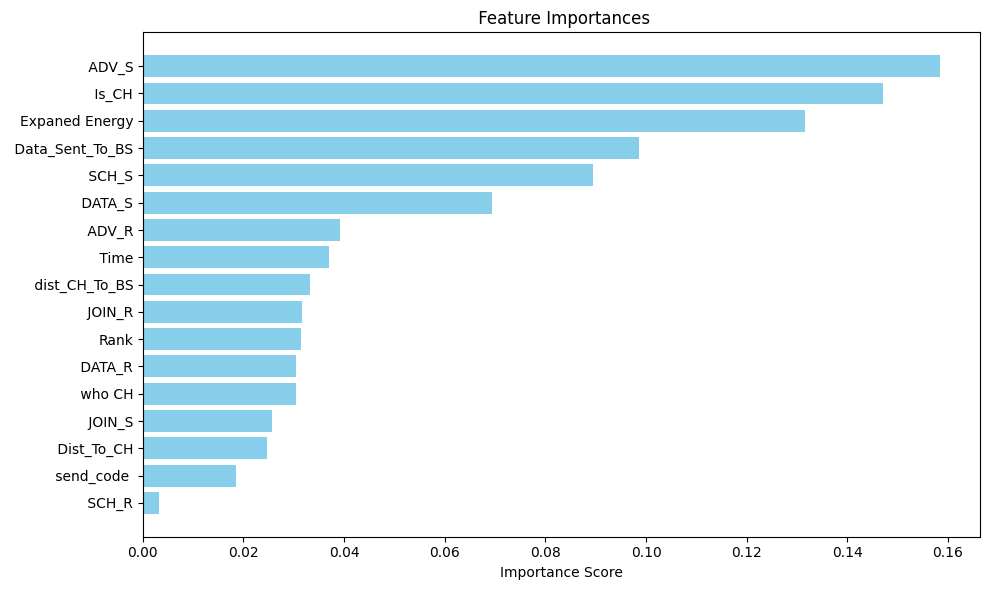

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=80, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print top features
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title(' Feature Importances')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()

In [61]:
top_features = importance_df['Feature'].head(8).tolist()
top_feature_indices = [np.where(feature_names == f)[0][0] for f in top_features]
X_train_selected = X_train[:, top_feature_indices]
X_test_selected= X_test[:, top_feature_indices]

In [62]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_selected = sc.fit_transform(X_train_selected)
X_test_selected = sc.transform(X_test_selected)

In [63]:
print(X_train_selected)

[[-0.12716634 -0.34880481 -0.38572764 ... -0.50062243 -0.26382666
   0.79499733]
 [-0.12716634 -0.34880481 -0.13439824 ...  1.99496516  0.16267739
   0.57391959]
 [ 0.32633035  2.86693294  0.48190617 ... -1.0603804   2.72170171
   1.40296113]
 ...
 [-0.12716634 -0.34880481 -0.37732094 ... -0.36068294 -0.5481627
  -0.31039139]
 [-0.12716634 -0.34880481 -0.36886991 ... -0.2907132   0.02050937
  -0.58673857]
 [-0.12716634 -0.34880481 -0.31946391 ...  0.22239827 -0.12165864
   0.07649466]]


In [64]:
print(X_test_selected)

[[-0.12716634 -0.34880481 -0.26744282 ...  0.71218649  0.02050937
  -0.75254688]
 [-0.12716634 -0.34880481 -0.31959688 ...  0.26904477 -0.12165864
  -0.75586305]
 [-0.12716634 -0.34880481 -0.30177881 ...  0.33901451 -0.26382666
  -0.86308575]
 ...
 [-0.12716634 -0.34880481 -0.41340032 ... -0.71053167 -0.5481627
  -0.97362462]
 [-0.12716634 -0.34880481 -0.39559702 ... -0.52394568 -0.40599468
  -0.36566083]
 [-0.12716634 -0.34880481 -0.38197491 ... -0.43065269 -0.40599468
   0.29757241]]


In [50]:
classifier = RandomForestClassifier(n_estimators=80, random_state=42)
classifier.fit(X_train_selected, y_train)

RandomForestClassifier(n_estimators=80, random_state=42)

In [51]:
y_pred = classifier.predict(X_test_selected)

In [52]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9950423402617398


In [53]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Blackhole       0.99      1.00      0.99      1486
    Flooding       0.93      0.98      0.95       621
    Grayhole       0.97      0.97      0.97      2283
      Normal       1.00      1.00      1.00     59345
        TDMA       0.97      0.93      0.95      1215

    accuracy                           1.00     64950
   macro avg       0.97      0.97      0.97     64950
weighted avg       1.00      1.00      1.00     64950



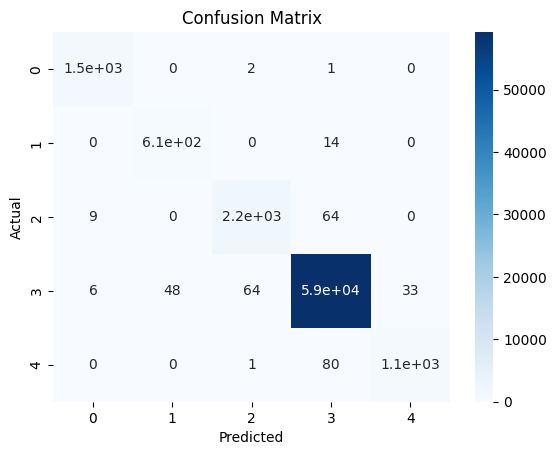

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()